# Notebook 01 — Data Ingestion & EDA
Explores the iris dataset: image quality, sharpness distribution, pupil-iris ratio.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Configuration ────────────────────────────
from pathlib import Path

# Adjust DATA_ROOT to where your images are
DATA_ROOT = Path('raw')
SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def collect_paths(root):
    paths = []
    for ext in SUPPORTED_EXTS:
        paths.extend(root.rglob(f'*{ext}'))
    return sorted(set(paths))

paths = collect_paths(DATA_ROOT)
print(f'Found {len(paths)} images under {DATA_ROOT}')

Found 384 images under raw


In [3]:
# ── Compute per-image stats ───────────────────
from tqdm import tqdm

def laplacian_sharpness(img):
    return float(cv2.Laplacian(img, cv2.CV_64F).var())

records = []
for p in tqdm(paths[:500], desc='Analyzing'):   # limit to 500 for speed
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    records.append({
        'path':      str(p),
        'sharpness': laplacian_sharpness(img),
        'mean':      float(img.mean()),
        'std':       float(img.std()),
        'h': img.shape[0], 'w': img.shape[1],
    })
print(f'Analysed {len(records)} images')


Analyzing:   0%| | 0/384 [


Analyzing:   1%| | 5/384 [


Analyzing:   3%| | 11/384 


Analyzing:   4%| | 17/384 


Analyzing:   6%| | 23/384 

...


Analyzing:  97%|▉| 372/384


Analyzing:  98%|▉| 378/384


Analyzing: 100%|█| 384/384


Analyzing: 100%|█| 384/384

Analysed 384 images


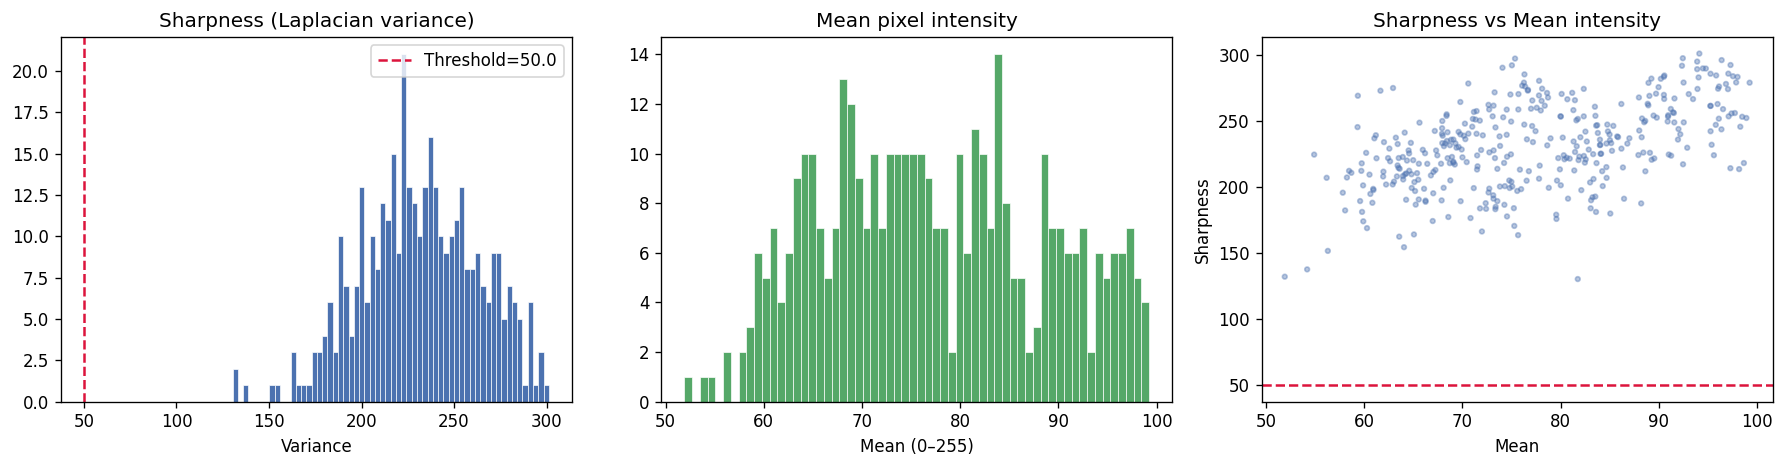

Blurry (below threshold): 0/384  (0.0%)


In [4]:
# ── Sharpness distribution ───────────────────
SHARP_THRESH = 50.0
sharpness = [r['sharpness'] for r in records]
means     = [r['mean']      for r in records]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sharpness, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.4)
axes[0].axvline(SHARP_THRESH, color='crimson', linestyle='--', label=f'Threshold={SHARP_THRESH}')
axes[0].set_title('Sharpness (Laplacian variance)')
axes[0].set_xlabel('Variance'); axes[0].legend()

axes[1].hist(means, bins=60, color='#55A868', edgecolor='white', linewidth=0.4)
axes[1].set_title('Mean pixel intensity')
axes[1].set_xlabel('Mean (0–255)')

c = ['crimson' if r['sharpness'] < SHARP_THRESH else '#4C72B0' for r in records]
axes[2].scatter(means, sharpness, c=c, alpha=0.4, s=8)
axes[2].axhline(SHARP_THRESH, color='crimson', linestyle='--')
axes[2].set_title('Sharpness vs Mean intensity')
axes[2].set_xlabel('Mean'); axes[2].set_ylabel('Sharpness')

plt.tight_layout(); plt.show()
n_blurry = sum(1 for r in records if r['sharpness'] < SHARP_THRESH)
print(f'Blurry (below threshold): {n_blurry}/{len(records)}  ({100*n_blurry/len(records):.1f}%)')

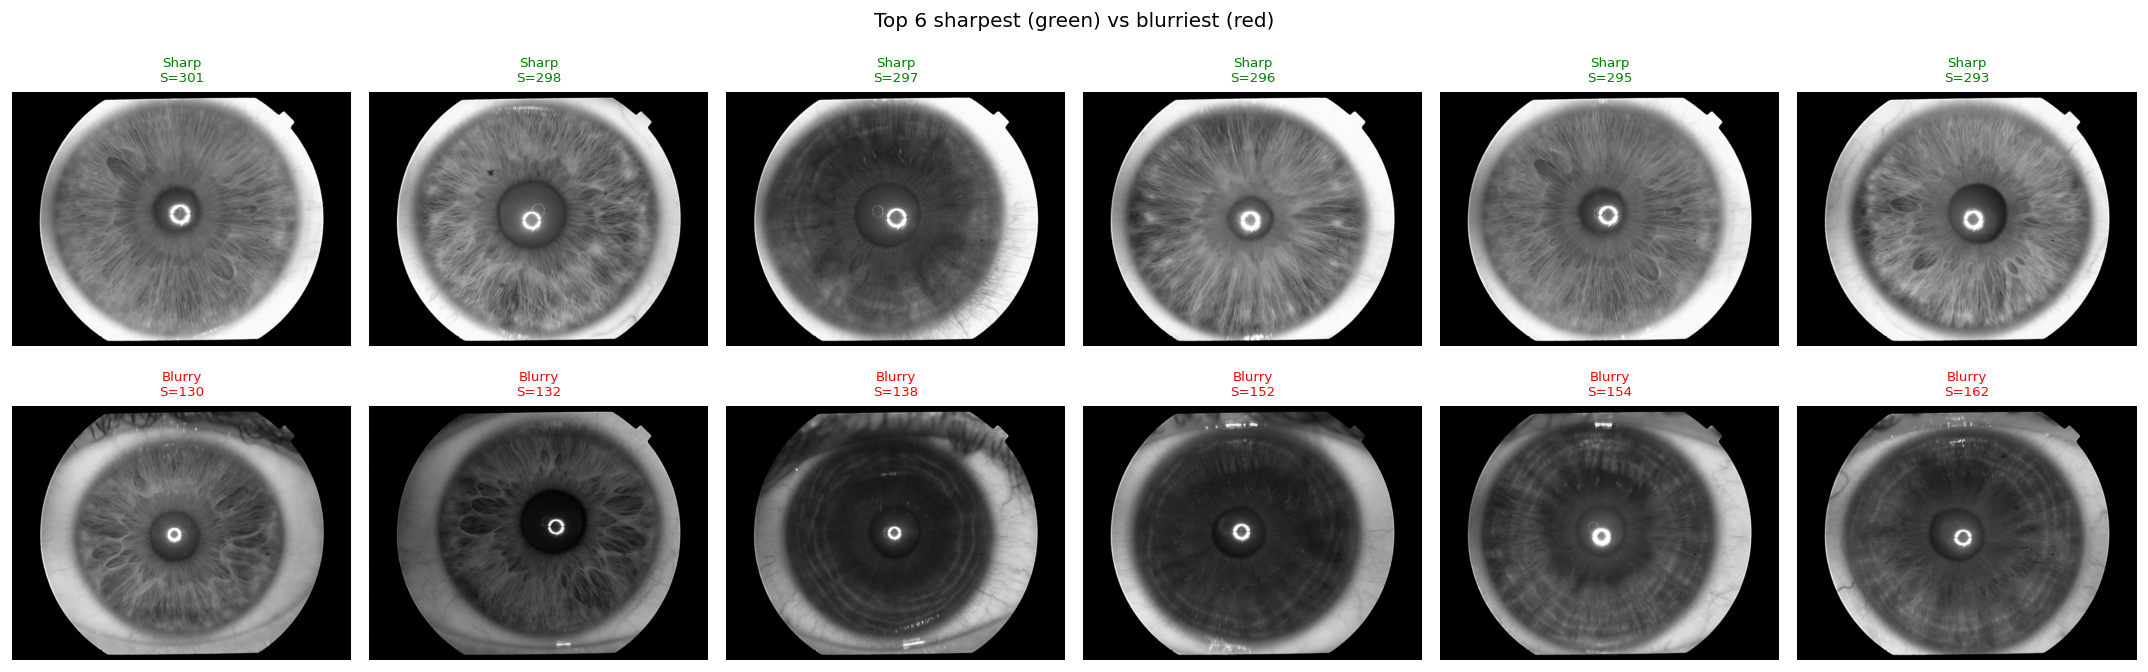

In [5]:
# ── Sample image grid ───────────────────────
sharp  = sorted(records, key=lambda r: -r['sharpness'])[:6]
blurry = sorted(records, key=lambda r:  r['sharpness'])[:6]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, (rec, title_color, row_label) in enumerate([
    *[(r, 'green', 'Sharp') for r in sharp],
    *[(r, 'red',   'Blurry') for r in blurry],
]):
    row, col = divmod(i, 6)
    img = cv2.imread(rec['path'], cv2.IMREAD_GRAYSCALE)
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f"{row_label}\nS={rec['sharpness']:.0f}",
                              fontsize=8, color=title_color)
    axes[row, col].axis('off')
plt.suptitle('Top 6 sharpest (green) vs blurriest (red)', fontsize=12)
plt.tight_layout(); plt.show()

In [6]:
# ── Run full Stage 1 (writes JSON + plots) ──
# Uncomment to execute the complete pipeline stage:
# Stage 1 CLI (writes clean_image_paths.txt):
# python prepare_data.py --stages 1